# A3 : Machine Translation

In [1]:
import torch, torchdata, torchtext
from torch import nn
import torch.nn.functional as F
import warnings
warnings.filterwarnings('ignore')
import random, math, time

device = torch.device('cuda:3' if torch.cuda.is_available() else 'cpu')
print(device)

#make our work comparable if restarted the kernel
SEED = 1234
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/opt/tljh/user/lib/python3.12/runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/opt/tljh/user/lib/python3.12/runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "/home/jupyter-st124371/venvs/ait-nlp/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/home/jupyter-st124371/venvs/ait-nlp/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start

cuda:3


# Loading the dataset and Splitting them

In [2]:
from torchdata.datapipes.iter import IterableWrapper, FileLister, FileOpener

SRC_FILE = 'train.en'
TRG_FILE = 'train.ne'

In [3]:
#this helper simply returns the text line and strips newlines
def de_serialize(tuple_data):
    return tuple_data[1].strip()

In [4]:
#load English lines
en_pipe = FileLister('.', masks=SRC_FILE).filter(lambda x: SRC_FILE in x)
en_pipe = FileOpener(en_pipe, mode='r')
en_pipe = en_pipe.readlines().map(de_serialize)

#load Nepali lines
ne_pipe = FileLister('.', masks=TRG_FILE).filter(lambda x: TRG_FILE in x)
ne_pipe = FileOpener(ne_pipe, mode='r')
ne_pipe = ne_pipe.readlines().map(de_serialize)

In [5]:
# zip them together to create (source,target) pairs -- making the dataset consistent with Multi30k datapipe object
train_dp = en_pipe.zip(ne_pipe)

In [6]:
sample = next(iter(train_dp))
print(f"Sample: {sample}")

Sample: ('It happened after the death of Saul, when David was returned from the slaughter of the Amalekites, and David had stayed two days in Ziklag;', 'दाऊदले अमालेकीहरूलाई हराएर पछि सिकलग गए। यो शाऊलको मृत्यु भएको केही दिन पछिको कुरा हो। दाऊद त्यहाँ दुइ दिन बसे।')


In [7]:
dataset_list = list(train_dp)
train_size = len(dataset_list)
print(train_size)

151937


In [8]:
# wrapping them into a DataPipe object for splitting
full_dp = IterableWrapper(dataset_list)

In [9]:
train_len = int(train_size * 0.7)
val_len = int(train_size * 0.2)
test_len = train_size - train_len - val_len

train, val, test = full_dp.random_split(
    total_length=train_size, 
    weights={"train": train_len, "val": val_len, "test": test_len}, 
    seed=999
)

In [10]:
print(f"Train size: {len(list(iter(train)))}")
print(f"Val size: {len(list(iter(val)))}")
print(f"Test size: {len(list(iter(test)))}")

Train size: 106355
Val size: 30387
Test size: 15195


# Tokenization and Numericalization

In [11]:
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator
from transformers import AutoTokenizer
from indicnlp.tokenize import indic_tokenize

Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.0
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [12]:
token_transform = {}
vocab_transform = {}
SRC_LANGUAGE = 'en'
TRG_LANGUAGE = 'ne'

In [13]:
token_transform[SRC_LANGUAGE] = get_tokenizer('basic_english')

In [14]:
def indic_tokenizer_wrapper(text):
    return indic_tokenize.trivial_tokenize(text, lang='ne')
token_transform[TRG_LANGUAGE] = indic_tokenizer_wrapper
print("using IndicNLP for Nepali")

using IndicNLP for Nepali


In [15]:
# yields list of tokens from the dataset
def yield_tokens(data_iter, language):
    language_index = {SRC_LANGUAGE: 0, TRG_LANGUAGE: 1}
    for data_sample in data_iter:
        text = data_sample[language_index[language]]
        yield token_transform[language](text)

In [16]:
UNK_IDX, PAD_IDX, SOS_IDX, EOS_IDX = 0, 1, 2, 3
special_symbols = ['<unk>', '<pad>', '<sos>', '<eos>']

In [17]:
# Numericalization happens here: mapping strings to unique integer IDs
for ln in [SRC_LANGUAGE, TRG_LANGUAGE]:
    vocab_transform[ln] = build_vocab_from_iterator(
        yield_tokens(train, ln),
        min_freq=20,
        specials=special_symbols,
        special_first=True
    )
    vocab_transform[ln].set_default_index(UNK_IDX)

print("Vocabularies built successfully.")

Vocabularies built successfully.


In [18]:
for ln in [SRC_LANGUAGE, TRG_LANGUAGE]:
    print(f"Language: {ln}")
    print(f"Total Unique Tokens found: {len(vocab_transform[ln])}")

Language: en
Total Unique Tokens found: 6159
Language: ne
Total Unique Tokens found: 7880


In [19]:
def text_transform_pipeline(text, ln):
    """Pipeline: Raw Text -> Tokens -> Indices (Numericalized)"""
    tokens = token_transform[ln](text)
    indices = vocab_transform[ln](tokens)
    return tokens, indices

In [20]:
random_sample = random.choice(dataset_list)
print(random_sample)
en_text, ne_text = random_sample

("It 's probably worth paying a premium for funds that invest in markets that are partially closed to foreign investors , such as South Korea , some specialists say .", 'दक्षिण कोरिया जस्ता विदेशी लगानीकर्ताहरूलाई आंशिक रूपले बन्द रहेका बजारमा लगानी गर्ने कोषहरूका लागि अधिक मूल्य भुक्तान गर्नु सायद उपयुक्त छ , केही विशेषज्ञहरू भन्छन् ।')


In [21]:
en_tokens, en_ids = text_transform_pipeline(en_text, SRC_LANGUAGE)
print(f"[English Raw]: {en_text}")
print(f"[English Tokens]: {en_tokens}")
print(f"[English IDs]: {en_ids}")

[English Raw]: It 's probably worth paying a premium for funds that invest in markets that are partially closed to foreign investors , such as South Korea , some specialists say .
[English Tokens]: ['it', "'", 's', 'probably', 'worth', 'paying', 'a', 'premium', 'for', 'funds', 'that', 'invest', 'in', 'markets', 'that', 'are', 'partially', 'closed', 'to', 'foreign', 'investors', ',', 'such', 'as', 'south', 'korea', ',', 'some', 'specialists', 'say', '.']
[English IDs]: [21, 16, 37, 1940, 2115, 4180, 11, 0, 13, 1804, 17, 3540, 10, 1516, 17, 25, 6100, 1280, 8, 306, 1951, 5, 119, 31, 745, 5412, 5, 110, 5458, 237, 6]


In [22]:
ne_tokens, ne_ids = text_transform_pipeline(ne_text, TRG_LANGUAGE)
print(f"[Nepali Raw]: {ne_text}")
print(f"[Nepali Tokens]: {ne_tokens}")
print(f"[Nepali IDs]: {ne_ids}")

[Nepali Raw]: दक्षिण कोरिया जस्ता विदेशी लगानीकर्ताहरूलाई आंशिक रूपले बन्द रहेका बजारमा लगानी गर्ने कोषहरूका लागि अधिक मूल्य भुक्तान गर्नु सायद उपयुक्त छ , केही विशेषज्ञहरू भन्छन् ।
[Nepali Tokens]: ['दक्षिण', 'कोरिया', 'जस्ता', 'विदेशी', 'लगानीकर्ताहरूलाई', 'आंशिक', 'रूपले', 'बन्द', 'रहेका', 'बजारमा', 'लगानी', 'गर्ने', 'कोषहरूका', 'लागि', 'अधिक', 'मूल्य', 'भुक्तान', 'गर्नु', 'सायद', 'उपयुक्त', 'छ', ',', 'केही', 'विशेषज्ञहरू', 'भन्छन्', '।']
[Nepali IDs]: [1164, 0, 547, 396, 0, 2599, 706, 223, 415, 971, 395, 19, 0, 15, 1484, 425, 7768, 58, 2661, 464, 7, 5, 49, 0, 709, 4]


In [23]:
en_vocab_list = vocab_transform[SRC_LANGUAGE].get_itos()
ne_vocab_list = vocab_transform[TRG_LANGUAGE].get_itos()

In [24]:
print(f"Total Unique English Tokens: {len(en_vocab_list)}")
print(f"Top 10 English: {en_vocab_list[:30]}")

Total Unique English Tokens: 6159
Top 10 English: ['<unk>', '<pad>', '<sos>', '<eos>', 'the', ',', '.', 'of', 'to', 'and', 'in', 'a', 'is', 'for', 'you', 'be', "'", 'that', 'will', 'this', 'not', 'it', 'on', 'with', 'he', 'are', 'i', 'from', 'have', 'by']


In [25]:
print(f"\nTotal Unique Nepali Tokens: {len(ne_vocab_list)}")
print(f"Top 10 Nepali: {ne_vocab_list[:30]}")


Total Unique Nepali Tokens: 7880
Top 10 Nepali: ['<unk>', '<pad>', '<sos>', '<eos>', '।', ',', 'र', 'छ', '.', 'गर्न', 'गर्नुहोस्', '-', 'पनि', 'अनि', 'यो', 'लागि', ')', '(', 'तर', 'गर्ने', 'भने', 'भएको', 'म', 'हो', 'तथा', 'थियो', ':', 'थिए', 'छन्', '"']


# DataLoader

In [26]:
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader

BATCH_SIZE = 32

# helper function to club together sequential operations
def sequential_transforms(*transforms):
    def func(txt_input):
        for transform in transforms:
            txt_input = transform(txt_input)
        return txt_input
    return func

# function to add BOS/EOS and create tensor for input sequence indices
MAX_LEN = 100 # Set this to a value that fits Puffers VRAM (e.g., 100-128)
def tensor_transform(token_ids):
    # Truncate if the sequence (plus SOS and EOS) exceeds MAX_LEN
    if len(token_ids) > (MAX_LEN - 2):
        token_ids = token_ids[:(MAX_LEN - 2)]
        
    return torch.cat((torch.tensor([SOS_IDX]), 
                      torch.tensor(token_ids), 
                      torch.tensor([EOS_IDX])))

# src and trg language text transforms to convert raw strings into tensors indices
text_transform = {}
for ln in [SRC_LANGUAGE, TRG_LANGUAGE]:
    text_transform[ln] = sequential_transforms(token_transform[ln], #Tokenization
                                               vocab_transform[ln], #Numericalization
                                               tensor_transform) # Add BOS/EOS and create tensor


# function to collate data samples into batch tesors
def collate_batch(batch):
    src_batch, src_len_batch, trg_batch = [], [], []
    for src_sample, trg_sample in batch:
        processed_text = text_transform[SRC_LANGUAGE](src_sample.rstrip("\n"))
        src_batch.append(processed_text)
        trg_batch.append(text_transform[TRG_LANGUAGE](trg_sample.rstrip("\n")))
        src_len_batch.append(processed_text.size(0))

    #add .long() at the end of these two lines
    src_batch = pad_sequence(src_batch, padding_value=PAD_IDX).long()
    trg_batch = pad_sequence(trg_batch, padding_value=PAD_IDX).long()
    
    return src_batch, torch.tensor(src_len_batch, dtype=torch.int64), trg_batch

In [27]:

train_dataloader = DataLoader(train, batch_size=BATCH_SIZE, collate_fn=collate_batch)
val_dataloader = DataLoader(val, batch_size=BATCH_SIZE, collate_fn=collate_batch)
test_dataloader = DataLoader(test, batch_size=BATCH_SIZE, collate_fn=collate_batch)

for src, src_len, trg in train_dataloader:
    print(f"Source batch shape: {src.shape}") # [max_seq_len, batch_size]
    print(f"Source lengths: {src_len}")
    print(f"Target batch shape: {trg.shape}")
    break

Source batch shape: torch.Size([54, 32])
Source lengths: tensor([54, 48, 25, 40, 24, 23, 31, 24, 14, 20, 36, 34, 27, 22, 33, 50, 27, 26,
        37, 29, 30, 32, 22, 25, 51, 30, 39, 29, 24, 41, 36, 37])
Target batch shape: torch.Size([46, 32])


# Modeling

In [28]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, src_pad_idx, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.src_pad_idx = src_pad_idx
        self.device = device
        
    def create_mask(self, src):
        mask = (src == self.src_pad_idx).permute(1, 0)
        return mask
        
    def forward(self, src, src_len, trg, teacher_forcing_ratio=0.5):
        batch_size = src.shape[1]
        trg_len = trg.shape[0]
        trg_vocab_size = self.decoder.output_dim
        
        outputs = torch.zeros(trg_len, batch_size, trg_vocab_size).to(self.device)
        
        encoder_outputs, hidden = self.encoder(src, src_len)
        
        input_ = trg[0, :]
        mask = self.create_mask(src)
        
        for t in range(1, trg_len):
            output, hidden, _ = self.decoder(input_, hidden, encoder_outputs, mask)
            outputs[t] = output
            
            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.argmax(1)
            input_ = trg[t] if teacher_force else top1
            
        return outputs

In [29]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hid_dim, dropout):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hid_dim, bidirectional=True)
        self.fc = nn.Linear(hid_dim * 2, hid_dim)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, src, src_len):
        # src: [src len, batch size]
        embedded = self.dropout(self.embedding(src))
        
        #pack sequence for GRU to ignore padding
        packed_embedded = nn.utils.rnn.pack_padded_sequence(embedded, src_len.to('cpu'), enforce_sorted=False)
        packed_outputs, hidden = self.rnn(packed_embedded)
        
        #unpack
        outputs, _ = nn.utils.rnn.pad_packed_sequence(packed_outputs)
        
        #combine bidirectional hidden states: [batch size, hid_dim]
        hidden = torch.tanh(self.fc(torch.cat((hidden[-2, :, :], hidden[-1, :, :]), dim=1)))
        
        return outputs, hidden

In [30]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hid_dim, dropout, attention):
        super().__init__()
        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim)
        self.rnn = nn.GRU((hid_dim * 2) + emb_dim, hid_dim)
        self.fc = nn.Linear((hid_dim * 2) + hid_dim + emb_dim, output_dim)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, input, hidden, encoder_outputs, mask):
        # input: [batch size]
        input = input.unsqueeze(0) # [1, batch size]
        embedded = self.dropout(self.embedding(input))
        
        #calculate attention weights
        a = self.attention(hidden, encoder_outputs, mask)
        a = a.unsqueeze(1) # [batch size, 1, src len]
        
        #context vector (weighted sum of encoder outputs)
        enc_perm = encoder_outputs.permute(1, 0, 2)
        weighted = torch.bmm(a, enc_perm).permute(1, 0, 2) # [1, batch size, hid dim * 2]
        
        #combine embedded input and context vector for GRU
        rnn_input = torch.cat((embedded, weighted), dim=2)
        output, hidden = self.rnn(rnn_input, hidden.unsqueeze(0))
        
        #final prediction
        embedded = embedded.squeeze(0)
        output = output.squeeze(0)
        weighted = weighted.squeeze(0)
        prediction = self.fc(torch.cat((output, weighted, embedded), dim=1))
        
        return prediction, hidden.squeeze(0), a.squeeze(1)

In [31]:
class Attention(nn.Module):
    def __init__(self, hid_dim, method="additive"):
        super().__init__()
        self.method = method
        
        if method == "additive":
            # Task 2.2: Additive Attention (Bahdanau)
            self.W = nn.Linear(hid_dim, hid_dim)      #for decoder hidden s
            self.U = nn.Linear(hid_dim * 2, hid_dim)  #for encoder outputs h
            self.v = nn.Linear(hid_dim, 1, bias=False)
        elif method == "general":
            # Task 2.1: General Attention (Luong)
            # Equation: s^T W h
            self.W = nn.Linear(hid_dim * 2, hid_dim)
            
    def forward(self, hidden, encoder_outputs, mask):
        # hidden: [batch size, hid dim] (s)
        # encoder_outputs: [src len, batch size, hid dim * 2] (h)
        batch_size = encoder_outputs.shape[1]
        src_len = encoder_outputs.shape[0]
        
        if self.method == "additive":
            #repeat hidden state for every source token
            hidden_repeated = hidden.unsqueeze(1).repeat(1, src_len, 1)
            enc_perm = encoder_outputs.permute(1, 0, 2)
            energy = self.v(torch.tanh(self.W(hidden_repeated) + self.U(enc_perm))).squeeze(2)
            
        elif self.method == "general":
            #project encoder outputs to match decoder dimension
            projected_encoder = self.W(encoder_outputs) # [src_len, batch, hid_dim]
            projected_encoder = projected_encoder.permute(1, 2, 0) # [batch, hid_dim, src_len]
            
            s = hidden.unsqueeze(1) # [batch, 1, hid_dim]
            
            #batch matrix multiplication (dot product)
            energy = torch.bmm(s, projected_encoder).squeeze(1) # [batch, src_len]

        # Apply mask to ignore padding tokens in attention
        # energy = energy.masked_fill(mask, -1e10)
        # using a float16 safe mask value
        energy = energy.masked_fill(mask, -1e4)
        return F.softmax(energy, dim=1)

# Training

In [32]:
def initialize_weights(m):
    for name, param in m.named_parameters():
        if 'weight' in name:
            nn.init.normal_(param.data, mean=0, std=0.01)
        else:
            nn.init.constant_(param.data, 0)

In [33]:
INPUT_DIM = len(vocab_transform[SRC_LANGUAGE])
OUTPUT_DIM = len(vocab_transform[TRG_LANGUAGE])
ENC_EMB_DIM = 256
DEC_EMB_DIM = 256
HID_DIM = 512
ENC_DROPOUT = 0.5
DEC_DROPOUT = 0.5


# General Attention (Task 2.1) 
attn_gen = Attention(HID_DIM, method="general")
enc_gen = Encoder(INPUT_DIM, ENC_EMB_DIM, HID_DIM, ENC_DROPOUT)
dec_gen = Decoder(OUTPUT_DIM, DEC_EMB_DIM, HID_DIM, DEC_DROPOUT, attn_gen)
model_general = Seq2Seq(enc_gen, dec_gen, PAD_IDX, device).to(device)
model_general.apply(initialize_weights)
print("Model with General Attention initialized.")

# Additive Attention (Task 2.2)
attn_add = Attention(HID_DIM, method="additive")
enc_add = Encoder(INPUT_DIM, ENC_EMB_DIM, HID_DIM, ENC_DROPOUT)
dec_add = Decoder(OUTPUT_DIM, DEC_EMB_DIM, HID_DIM, DEC_DROPOUT, attn_add)
model_additive = Seq2Seq(enc_add, dec_add, PAD_IDX, device).to(device)
model_additive.apply(initialize_weights)
print("Model with Additive Attention initialized.")




Model with General Attention initialized.
Model with Additive Attention initialized.


In [34]:
def count_parameters_debug(model):
    print(f'{"Layer Name":<25} | {"Parameters":<10}')
    print("-" * 40)
    total = 0
    for name, p in model.named_parameters():
        if p.requires_grad:
            print(f'{name:<25} | {p.numel():<10}')
            total += p.numel()
    print("-" * 40)
    print(f'{"TOTAL":<25} | {total:<10}')

# Use it like this:
count_parameters_debug(model_general)

Layer Name                | Parameters
----------------------------------------
encoder.embedding.weight  | 1576704   
encoder.rnn.weight_ih_l0  | 393216    
encoder.rnn.weight_hh_l0  | 786432    
encoder.rnn.bias_ih_l0    | 1536      
encoder.rnn.bias_hh_l0    | 1536      
encoder.rnn.weight_ih_l0_reverse | 393216    
encoder.rnn.weight_hh_l0_reverse | 786432    
encoder.rnn.bias_ih_l0_reverse | 1536      
encoder.rnn.bias_hh_l0_reverse | 1536      
encoder.fc.weight         | 524288    
encoder.fc.bias           | 512       
decoder.attention.W.weight | 524288    
decoder.attention.W.bias  | 512       
decoder.embedding.weight  | 2017280   
decoder.rnn.weight_ih_l0  | 1966080   
decoder.rnn.weight_hh_l0  | 786432    
decoder.rnn.bias_ih_l0    | 1536      
decoder.rnn.bias_hh_l0    | 1536      
decoder.fc.weight         | 14120960  
decoder.fc.bias           | 7880      
----------------------------------------
TOTAL                     | 23893448  


In [35]:
def count_parameters(model):
    params = [p.numel() for p in model.parameters() if p.requires_grad]
    for item in params:
        print(f'{item:>6}')
    print(f'______\n{sum(params):>6}')
    

In [36]:
count_parameters(model_general)

1576704
393216
786432
  1536
  1536
393216
786432
  1536
  1536
524288
   512
524288
   512
2017280
1966080
786432
  1536
  1536
14120960
  7880
______
23893448


In [37]:
count_parameters(model_additive)

1576704
393216
786432
  1536
  1536
393216
786432
  1536
  1536
524288
   512
262144
   512
524288
   512
   512
2017280
1966080
786432
  1536
  1536
14120960
  7880
______
24156616


In [38]:
import torch.optim as optim
import os

class Trainer:
    def __init__(self, model, model_name, train_loader, val_loader, device, lr=0.001, patience=3):
        self.model = model
        self.model_name = model_name
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.device = device
        
        self.optimizer = optim.Adam(model.parameters(), lr=lr)
        self.criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
        self.clip = 1
        
        self.best_valid_loss = float('inf')
        self.patience = patience
        #for early stopping
        self.counter = 0  
        
        #directory for checkpoints
        os.makedirs('checkpoints', exist_ok=True)
        self.save_path = f'checkpoints/{self.model_name}_best.pt'
        self.checkpoint_path = f'checkpoints/{self.model_name}_last.pt'
        #adding this because out of memory error
        self.scaler = torch.cuda.amp.GradScaler()

    def save_checkpoint(self, epoch, valid_loss, is_best=False):
        state = {
            'epoch': epoch,
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'valid_loss': valid_loss,
        }
        torch.save(state, self.checkpoint_path)
        if is_best:
            torch.save(state, self.save_path)
            print(f"  [Checkpoint] New best model saved to {self.save_path}")

    def load_checkpoint(self, path):
        if os.path.exists(path):
            checkpoint = torch.load(path)
            self.model.load_state_dict(checkpoint['model_state_dict'])
            self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
            print(f"  [Resume] Loaded checkpoint from {path} (Epoch {checkpoint['epoch']+1})")
            return checkpoint['epoch'] + 1
        return 0
    def run_epoch(self, loader, is_train=True):
        self.model.train() if is_train else self.model.eval()
        epoch_loss = 0
        
        with torch.set_grad_enabled(is_train):
            for src, src_len, trg in loader:
                src, trg = src.to(self.device), trg.to(self.device)
                
                if is_train: self.optimizer.zero_grad()
                
                # Use autocast for the forward pass
                with torch.cuda.amp.autocast():
                    output = self.model(src, src_len, trg, 0.5 if is_train else 0)
                    output_dim = output.shape[-1]
                    output = output[1:].view(-1, output_dim)
                    trg = trg[1:].view(-1)
                    loss = self.criterion(output, trg)
                
                if is_train:
                    # Scales loss, calls backward(), then unscales gradients for clipping
                    self.scaler.scale(loss).backward()
                    self.scaler.unscale_(self.optimizer)
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.clip)
                    self.scaler.step(self.optimizer)
                    self.scaler.update()
                
                epoch_loss += loss.item()
        return epoch_loss / len(loader)

    def train_model(self, num_epochs, resume=False):
        start_epoch = 0
        if resume:
            start_epoch = self.load_checkpoint(self.checkpoint_path)

        print(f"\n--- Starting training for: {self.model_name} ---")
        for epoch in range(start_epoch, num_epochs):
            start_time = time.time()
            
            train_loss = self.run_epoch(self.train_loader, is_train=True)
            valid_loss = self.run_epoch(self.val_loader, is_train=False)
            
            end_time = time.time()
            mins, secs = int((end_time - start_time) // 60), int((end_time - start_time) % 60)

            # Check if best
            is_best = valid_loss < self.best_valid_loss
            if is_best:
                self.best_valid_loss = valid_loss
                self.counter = 0 # reset patience
            else:
                self.counter += 1

            self.save_checkpoint(epoch, valid_loss, is_best)

            print(f'Epoch: {epoch+1:02} | Time: {mins}m {secs}s')
            print(f'\tTrain Loss: {train_loss:.3f} | Train PPL: {math.exp(train_loss):7.3f}')
            print(f'\t Val. Loss: {valid_loss:.3f} |  Val. PPL: {math.exp(valid_loss):7.3f}')

            if self.counter >= self.patience:
                print(f"Early stopping triggered after {epoch+1} epochs.")
                break

In [39]:
general_trainer = Trainer(
    model=model_general, 
    model_name="General_Attention",
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    device=device,
    patience=3
)

In [40]:
# to continue training use resume=True
general_trainer.train_model(num_epochs=15, resume=False)


--- Starting training for: General_Attention ---
  [Checkpoint] New best model saved to checkpoints/General_Attention_best.pt
Epoch: 01 | Time: 8m 43s
	Train Loss: 4.834 | Train PPL: 125.695
	 Val. Loss: 5.744 |  Val. PPL: 312.445
  [Checkpoint] New best model saved to checkpoints/General_Attention_best.pt
Epoch: 02 | Time: 8m 33s
	Train Loss: 4.073 | Train PPL:  58.749
	 Val. Loss: 5.263 |  Val. PPL: 193.099
  [Checkpoint] New best model saved to checkpoints/General_Attention_best.pt
Epoch: 03 | Time: 8m 33s
	Train Loss: 3.699 | Train PPL:  40.406
	 Val. Loss: 5.085 |  Val. PPL: 161.539
  [Checkpoint] New best model saved to checkpoints/General_Attention_best.pt
Epoch: 04 | Time: 8m 33s
	Train Loss: 3.463 | Train PPL:  31.907
	 Val. Loss: 5.008 |  Val. PPL: 149.566
  [Checkpoint] New best model saved to checkpoints/General_Attention_best.pt
Epoch: 05 | Time: 8m 34s
	Train Loss: 3.292 | Train PPL:  26.894
	 Val. Loss: 5.005 |  Val. PPL: 149.229
  [Checkpoint] New best model saved to c

In [41]:
additive_trainer = Trainer(
    model=model_additive, 
    model_name="Additive_Attention",
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    device=device,
    patience=3
)

In [42]:
additive_trainer.train_model(num_epochs=10, resume=False)


--- Starting training for: Additive_Attention ---
  [Checkpoint] New best model saved to checkpoints/Additive_Attention_best.pt
Epoch: 01 | Time: 9m 49s
	Train Loss: 4.676 | Train PPL: 107.392
	 Val. Loss: 5.497 |  Val. PPL: 243.907
  [Checkpoint] New best model saved to checkpoints/Additive_Attention_best.pt
Epoch: 02 | Time: 9m 47s
	Train Loss: 3.832 | Train PPL:  46.156
	 Val. Loss: 4.999 |  Val. PPL: 148.241
  [Checkpoint] New best model saved to checkpoints/Additive_Attention_best.pt
Epoch: 03 | Time: 9m 46s
	Train Loss: 3.445 | Train PPL:  31.351
	 Val. Loss: 4.886 |  Val. PPL: 132.387
  [Checkpoint] New best model saved to checkpoints/Additive_Attention_best.pt
Epoch: 04 | Time: 9m 47s
	Train Loss: 3.207 | Train PPL:  24.712
	 Val. Loss: 4.874 |  Val. PPL: 130.819
  [Checkpoint] New best model saved to checkpoints/Additive_Attention_best.pt
Epoch: 05 | Time: 9m 47s
	Train Loss: 3.042 | Train PPL:  20.955
	 Val. Loss: 4.810 |  Val. PPL: 122.729
  [Checkpoint] New best model save

KeyboardInterrupt: 

# Visualization

Since, I did not store the losses in a variable. I am using the output from above to plot them. I wanted to re-run the experiment by storing the variable but the OutOfMemory error in the Puffer server was a huge issue! Thus, the outputs have been derived from the logs. 

In [43]:
import pandas as pd

# Verification Table
data = {
    'Metric': ['Best Val Loss', 'Best Val PPL', 'Avg Time/Epoch'],
    'General': [4.945, 140.514, '8m 35s'],
    'Additive': [4.796, 120.988, '9m 47s']
}
print(pd.DataFrame(data).to_string(index=False))

        Metric  General Additive
 Best Val Loss    4.945    4.796
  Best Val PPL  140.514  120.988
Avg Time/Epoch   8m 35s   9m 47s


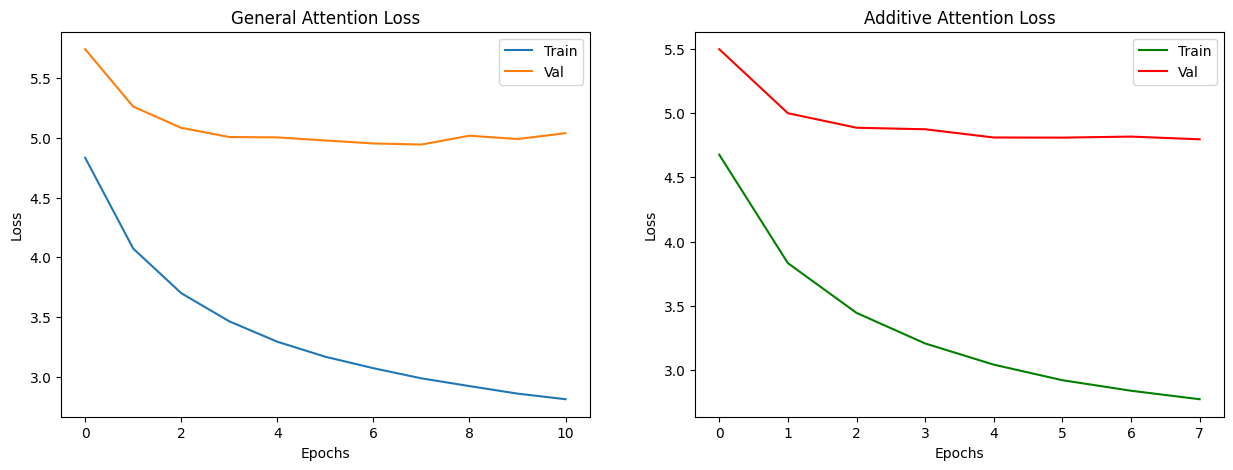

In [44]:
import matplotlib.pyplot as plt

gen_train = [4.834, 4.073, 3.699, 3.463, 3.292, 3.166, 3.070, 2.985, 2.920, 2.857, 2.810]
gen_val = [5.744, 5.263, 5.085, 5.008, 5.005, 4.979, 4.954, 4.945, 5.019, 4.991, 5.040]

add_train = [4.676, 3.832, 3.445, 3.207, 3.042, 2.921, 2.839, 2.773]
add_val = [5.497, 4.999, 4.886, 4.874, 4.810, 4.809, 4.817, 4.796]

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].plot(gen_train, label='Train')
ax[0].plot(gen_val, label='Val')
ax[0].set_title('General Attention Loss')
ax[0].legend()

ax[1].plot(add_train, label='Train', color='green')
ax[1].plot(add_val, label='Val', color='red')
ax[1].set_title('Additive Attention Loss')
ax[1].legend()

for a in ax:
    a.set_xlabel('Epochs')
    a.set_ylabel('Loss')

plt.show()

In [75]:
import pickle
import os

os.makedirs('assets', exist_ok=True)

# Save the vocab_transform dictionary
with open('assets/vocab_transform.pkl', 'wb') as f:
    pickle.dump(vocab_transform, f)

print("vocab_transform.pkl has been saved in the assets folder.")

vocab_transform.pkl has been saved in the assets folder.
